In [23]:
import sqlite3
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [24]:
df = pd.read_csv('Hackathon-3 data.csv')    
print(f"Dataset loaded")

Dataset loaded


In [25]:
grade_map = {
    "A+": 9, "A": 8,
    "B+": 7, "B": 6,
    "C+": 5,  "D": 4,
    "D": 3,  "E": 2,
    "NC": 0
}

df = df.replace(grade_map)

C:\Users\PARTH\AppData\Local\Temp\ipykernel_12372\116064608.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace(grade_map)


In [26]:
# #optional 
# db_path = os.path.join("..", "Database", "grades.db")
# conn = sqlite3.connect(db_path)

# df = pd.read_sql_query("SELECT * FROM student_grades", conn)
# conn.close()

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Calculus-1      49 non-null     object 
 1   Calculus-2      49 non-null     object 
 2   Python-1        49 non-null     object 
 3   Python-2        49 non-null     object 
 4   SM-1            49 non-null     object 
 5   SM-2            49 non-null     int64  
 6   ML-1(Expected)  0 non-null      float64
dtypes: float64(1), int64(1), object(5)
memory usage: 2.8+ KB


In [28]:
df.describe()

,SM-2,ML-1(Expected)
count,49.000000,0.0
mean,5.959184,NaN
std,2.101182,NaN
min,0.000000,NaN
25%,5.000000,NaN
50%,7.000000,NaN
75%,7.000000,NaN
max,9.000000,NaN


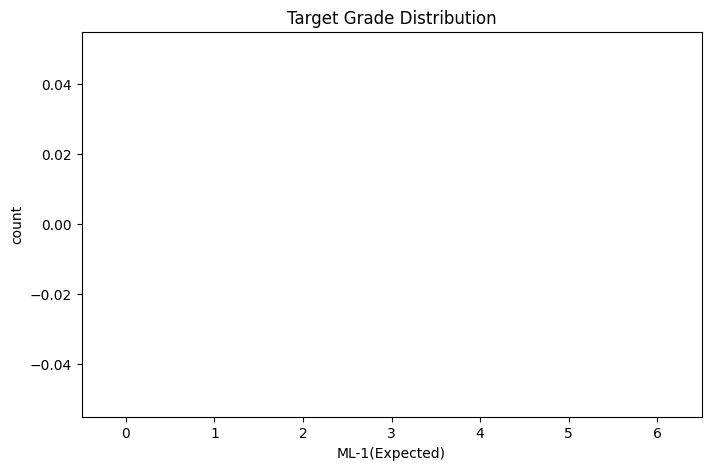

ValueError: could not convert string to float: 'C'

<Figure size 1000x800 with 0 Axes>

In [29]:
df = df.replace(grade_map)

plt.figure(figsize=(8,5))
sns.countplot(x="ML-1(Expected)", data=df)
plt.title("Target Grade Distribution")
plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:
X = df.drop(columns=["ML-1(Expected)"])
y = df["ML-1(Expected)"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

results = {}

print("\nModel Performance:\n")

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print(f"{name}: Accuracy = {acc:.3f}")

In [ ]:
best_model = max(results, key=results.get)

print("\nBest Model:", best_model)
print("Accuracy:", results[best_model])